# Notebook 12: Neural Collaborative Filtering (NCF)

Este notebook implementa **Neural Collaborative Filtering (NCF)** siguiendo la arquitectura propuesta por He et al. (2017).

## Objetivos:
1. Implementar NCF combinando GMF (Generalized Matrix Factorization) y MLP
2. Evaluar el impacto de Deep Learning en consumo energético vs métodos tradicionales
3. Analizar variantes energéticas (diferentes embedding dimensions)
4. Comparar rendimiento en diferentes fracciones del dataset

## Variantes energéticas evaluadas:
- **embedding_dim**: 20, 50, 100 (menor dimensión = menor consumo)
- **Fracciones**: 10%, 25%, 50%, 75% del dataset

## Métricas:
- RMSE, MAE (precisión predictiva)
- Emisiones CO2 (sostenibilidad)
- Número de parámetros (complejidad del modelo)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from codecarbon import EmissionsTracker
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Dataset personalizado para PyTorch

Convierte el DataFrame de pandas en un Dataset de PyTorch para usar con DataLoader.

In [2]:
class MovieLensDataset(Dataset):
    """Dataset de PyTorch para MovieLens 1M"""
    
    def __init__(self, df):
        """
        Args:
            df: DataFrame con columnas ['userId', 'movieId', 'rating']
        """
        self.users = torch.LongTensor(df['userId'].values)
        self.items = torch.LongTensor(df['movieId'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

## 2. Arquitectura Neural Collaborative Filtering

### Componentes:
1. **GMF (Generalized Matrix Factorization)**: Producto elemento a elemento de embeddings usuario-ítem
2. **MLP (Multi-Layer Perceptron)**: Red neuronal que concatena embeddings usuario-ítem
3. **Fusion Layer**: Combina las salidas de GMF y MLP para la predicción final

### Arquitectura:
```
User Embedding (GMF) ──┐
                       ├──> Element-wise Product ──┐
Item Embedding (GMF) ──┘                           │
                                                    ├──> Concatenate ──> Output Layer
User Embedding (MLP) ──┐                           │
                       ├──> Concatenate ──> MLP ───┘
Item Embedding (MLP) ──┘
```

In [ ]:
class NeuralCF(nn.Module):
    """Neural Collaborative Filtering (He et al., 2017)"""
    
    def __init__(self, n_users, n_items, embedding_dim=50, layers=[64, 32, 16], dropout=0.2):
        """
        Args:
            n_users: Número total de usuarios
            n_items: Número total de ítems
            embedding_dim: Dimensión de los embeddings (menor = más eficiente)
            layers: Lista con el tamaño de cada capa oculta del MLP
            dropout: Tasa de dropout para regularización
        """
        super().__init__()
        
        self.embedding_dim = embedding_dim
        self.layers = layers
        
        self.user_emb_gmf = nn.Embedding(n_users, embedding_dim)
        self.item_emb_gmf = nn.Embedding(n_items, embedding_dim)
        
        self.user_emb_mlp = nn.Embedding(n_users, embedding_dim)
        self.item_emb_mlp = nn.Embedding(n_items, embedding_dim)
        
        mlp_modules = []
        input_size = embedding_dim * 2
        
        for layer_size in layers:
            mlp_modules.append(nn.Linear(input_size, layer_size))
            mlp_modules.append(nn.ReLU())
            mlp_modules.append(nn.Dropout(dropout))
            input_size = layer_size
        
        self.mlp = nn.Sequential(*mlp_modules)
        
        self.output = nn.Linear(layers[-1] + embedding_dim, 1)
        
        self._init_weights()
    
    def _init_weights(self):
        """Inicialización de pesos siguiendo He et al. 2017"""
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, user_ids, item_ids):
        """
        Forward pass del modelo
        
        Args:
            user_ids: Tensor de IDs de usuarios [batch_size]
            item_ids: Tensor de IDs de ítems [batch_size]
        
        Returns:
            Predicciones de rating [batch_size]
        """
        user_gmf = self.user_emb_gmf(user_ids)
        item_gmf = self.item_emb_gmf(item_ids)
        gmf_out = user_gmf * item_gmf 
        
        user_mlp = self.user_emb_mlp(user_ids) 
        item_mlp = self.item_emb_mlp(item_ids)  
        mlp_input = torch.cat([user_mlp, item_mlp], dim=-1)  
        mlp_out = self.mlp(mlp_input)
        
        concat = torch.cat([gmf_out, mlp_out], dim=-1)  
        pred = self.output(concat).squeeze()            
        
        return pred
    
    def get_num_params(self):
        """Retorna el número total de parámetros del modelo"""
        return sum(p.numel() for p in self.parameters())

## 3. Función de entrenamiento con medición de carbono

Esta función:
1. Entrena el modelo NCF usando Adam optimizer
2. Mide el consumo energético con CodeCarbon
3. Evalúa en el conjunto de test
4. Retorna métricas de precisión y sostenibilidad

In [ ]:
def train_ncf(train_df, test_df, embedding_dim=50, epochs=10, batch_size=1024, lr=0.001, verbose=True):
    """
    Entrena NCF con medición de carbono
    
    Args:
        train_df: DataFrame de entrenamiento con ['userId', 'movieId', 'rating']
        test_df: DataFrame de test
        embedding_dim: Dimensión de embeddings (20, 50, 100 para variantes energéticas)
        epochs: Número de épocas de entrenamiento
        batch_size: Tamaño del batch
        lr: Learning rate
        verbose: Si True, imprime progreso
    
    Returns:
        dict: Diccionario con métricas (rmse, mae, emissions_kg, n_params)
    """
    
    n_users = max(train_df['userId'].max(), test_df['userId'].max()) + 1
    n_items = max(train_df['movieId'].max(), test_df['movieId'].max()) + 1
    
    if verbose:
        print(f"n_users: {n_users}, n_items: {n_items}")
        print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
    
    train_dataset = MovieLensDataset(train_df)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    
    test_dataset = MovieLensDataset(test_df)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    model = NeuralCF(n_users, n_items, embedding_dim=embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    if verbose:
        print(f"Modelo inicializado con {model.get_num_params():,} parámetros")
    
    tracker = EmissionsTracker(
        project_name=f"NCF_emb{embedding_dim}",
        output_dir="../results",
        log_level="error" 
    )
    tracker.start()
    
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        batch_count = 0
        
        for users, items, ratings in train_loader:
            optimizer.zero_grad()
            
            preds = model(users, items)
            loss = criterion(preds, ratings)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            batch_count += 1
        
        avg_loss = total_loss / batch_count
        
        if verbose and epoch % 2 == 0:
            print(f"Epoch {epoch:2d}/{epochs}: Loss = {avg_loss:.4f}")
    
    emissions = tracker.stop()
    
    model.eval()
    all_preds = []
    all_ratings = []
    
    with torch.no_grad():
        for users, items, ratings in test_loader:
            preds = model(users, items)
            all_preds.extend(preds.cpu().numpy())
            all_ratings.extend(ratings.cpu().numpy())
    
    rmse = np.sqrt(mean_squared_error(all_ratings, all_preds))
    mae = mean_absolute_error(all_ratings, all_preds)
    
    results = {
        'rmse': rmse,
        'mae': mae,
        'emissions_kg': emissions,
        'embedding_dim': embedding_dim,
        'n_params': model.get_num_params(),
        'epochs': epochs,
        'batch_size': batch_size
    }
    
    return results

## 4. Carga de datos

Cargamos el conjunto de test (fijo) y los diferentes subconjuntos de entrenamiento generados previamente.

In [ ]:
data_path = Path("../data/processed")

test = pd.read_csv(data_path / "test.csv")

print(f"Test set cargado: {len(test)} ratings")
print(f"Usuarios únicos en test: {test['userId'].nunique()}")
print(f"Películas únicas en test: {test['movieId'].nunique()}")

Test set cargado: 6040 ratings
Usuarios únicos en test: 6040
Películas únicas en test: 1874


## 5. Experimentos: Variantes energéticas

### Configuración experimental:

| Parámetro | Valores |
|-----------|----------|
| **Fracciones del dataset** | 10%, 25%, 50%, 75% |
| **Embedding dimensions** | 20, 50, 100 |
| **Epochs** | 10 |
| **Batch size** | 1024 |
| **Learning rate** | 0.001 |
| **Optimizer** | Adam |

### Hipótesis:
- **Menor embedding_dim** → Menos parámetros → Menor consumo energético → ¿Menor precisión?
- **Menor fracción** → Menos datos → Entrenamiento más rápido → ¿Suficiente información?

**Total de experimentos**: 4 fracciones × 3 dimensiones = **12 experimentos**

In [ ]:
fractions = [10, 25, 50, 75]
embedding_dims = [20, 50, 100]

results = []

print("="*70)
print("INICIANDO EXPERIMENTOS: Neural Collaborative Filtering")
print("="*70)
print(f"Total de experimentos: {len(fractions) * len(embedding_dims)}")
print()

experiment_count = 0

for fraction in fractions:
    train_file = data_path / "subsampled_informed" / f"ratings_top_items_{fraction}.csv"
    
    if not train_file.exists():
        print(f"ADVERTENCIA: {train_file} no existe, saltando...")
        continue
    
    train = pd.read_csv(train_file)
    
    for emb_dim in embedding_dims:
        experiment_count += 1
        
        print(f"\n{'='*70}")
        print(f"EXPERIMENTO {experiment_count}/{len(fractions) * len(embedding_dims)}")
        print(f"Fracción: {fraction}%, Embedding dim: {emb_dim}")
        print('='*70)
        
        try:
            result = train_ncf(
                train, 
                test, 
                embedding_dim=emb_dim, 
                epochs=10,
                batch_size=1024,
                lr=0.001,
                verbose=True
            )
            
            result.update({
                'method': f'NCF_emb{emb_dim}',
                'fraction': fraction,
                'sampling': 'informed_items',
                'train_size': len(train)
            })
            
            results.append(result)
            
            print(f"\nRESULTADOS:")
            print(f"   RMSE: {result['rmse']:.4f}")
            print(f"   MAE:  {result['mae']:.4f}")
            print(f"   CO2:  {result['emissions_kg']:.6f} kg")
            print(f"   Parámetros: {result['n_params']:,}")
            
        except Exception as e:
            print(f"\nERROR en experimento: {e}")
            continue

print(f"\n{'='*70}")
print(f"EXPERIMENTOS COMPLETADOS: {len(results)}/{len(fractions) * len(embedding_dims)}")
print('='*70)

INICIANDO EXPERIMENTOS: Neural Collaborative Filtering
Total de experimentos: 12


EXPERIMENTO 1/12
Fracción: 10%, Embedding dim: 20
n_users: 6041, n_items: 3953
Train size: 443904, Test size: 6040


[codecarbon WARNING @ 21:57:29] Multiple instances of codecarbon are allowed to run at the same time.


Modelo inicializado con 405,029 parámetros
Epoch  0/10: Loss = 3.3867
Epoch  2/10: Loss = 1.0236
Epoch  4/10: Loss = 0.7244
Epoch  6/10: Loss = 0.6345
Epoch  8/10: Loss = 0.5850

✅ RESULTADOS:
   RMSE: 2.4080
   MAE:  1.8897
   CO2:  0.000653 kg
   Parámetros: 405,029

EXPERIMENTO 2/12
Fracción: 10%, Embedding dim: 50
n_users: 6041, n_items: 3953
Train size: 443904, Test size: 6040
Modelo inicializado con 1,008,539 parámetros
Epoch  0/10: Loss = 2.8355
Epoch  2/10: Loss = 0.9311
Epoch  4/10: Loss = 0.5925
Epoch  6/10: Loss = 0.4844
Epoch  8/10: Loss = 0.4155

✅ RESULTADOS:
   RMSE: 2.4249
   MAE:  1.8392
   CO2:  0.000809 kg
   Parámetros: 1,008,539

EXPERIMENTO 3/12
Fracción: 10%, Embedding dim: 100
n_users: 6041, n_items: 3953
Train size: 443904, Test size: 6040
Modelo inicializado con 2,014,389 parámetros
Epoch  0/10: Loss = 2.9020
Epoch  2/10: Loss = 0.8154
Epoch  4/10: Loss = 0.4934
Epoch  6/10: Loss = 0.3458
Epoch  8/10: Loss = 0.2578

✅ RESULTADOS:
   RMSE: 2.4611
   MAE:  1.818

## 6. Guardar resultados

Los resultados se guardan en formato CSV para análisis posterior y generación de tablas/figuras.

In [ ]:
if len(results) > 0:
    df_results = pd.DataFrame(results)
    
    df_results = df_results.sort_values(['fraction', 'embedding_dim'])
    
    output_file = Path("../results/ncf_results.csv")
    df_results.to_csv(output_file, index=False)
    
    print(f"\nResultados guardados en: {output_file}")
    print(f"\nResumen de resultados:")
    print(df_results[['method', 'fraction', 'rmse', 'mae', 'emissions_kg', 'n_params']].to_string(index=False))
else:
    print("\n No hay resultados para guardar")


✅ Resultados guardados en: ..\results\ncf_results.csv

Resumen de resultados:
    method  fraction     rmse      mae  emissions_kg  n_params
 NCF_emb20        10 2.408004 1.889682      0.000653    405029
 NCF_emb50        10 2.424886 1.839188      0.000809   1008539
NCF_emb100        10 2.461119 1.818280      0.001046   2014389
 NCF_emb20        25 1.730783 1.209608      0.001036    405029
 NCF_emb50        25 1.651212 1.071549      0.001226   1008539
NCF_emb100        25 1.693624 1.029695      0.001545   2014389
 NCF_emb20        50 0.841305 0.616475      0.001356    405029
 NCF_emb50        50 0.782359 0.506778      0.001602   1008539
NCF_emb100        50 0.820061 0.436400      0.001913   2014389
 NCF_emb20        75 0.744487 0.557595      0.001442    405029
 NCF_emb50        75 0.608091 0.418087      0.001720   1008539
NCF_emb100        75 0.464599 0.283280      0.002155   2014389


## 7. Análisis preliminar

Comparación rápida de las variantes energéticas.


✅ Gráfico preliminar guardado en results/ncf_preliminary_analysis.png


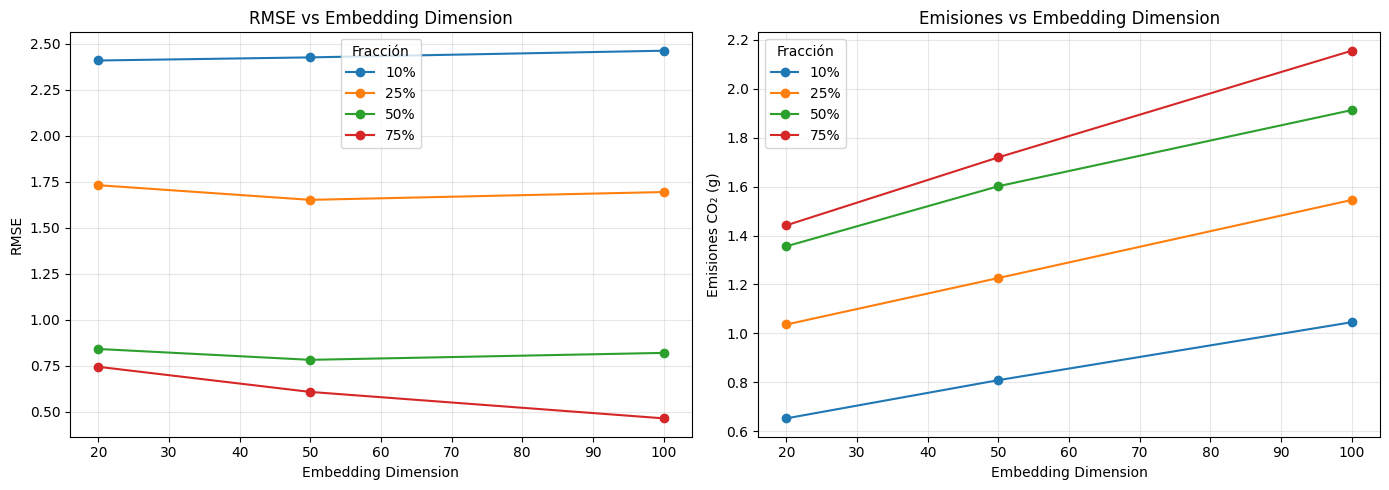

In [ ]:
if len(results) > 0:
    import matplotlib.pyplot as plt
    
    df_results = pd.DataFrame(results)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for fraction in df_results['fraction'].unique():
        data = df_results[df_results['fraction'] == fraction]
        axes[0].plot(data['embedding_dim'], data['rmse'], marker='o', label=f'{fraction}%')
    
    axes[0].set_xlabel('Embedding Dimension')
    axes[0].set_ylabel('RMSE')
    axes[0].set_title('RMSE vs Embedding Dimension')
    axes[0].legend(title='Fracción')
    axes[0].grid(alpha=0.3)
    
    for fraction in df_results['fraction'].unique():
        data = df_results[df_results['fraction'] == fraction]
        axes[1].plot(data['embedding_dim'], data['emissions_kg']*1000, marker='o', label=f'{fraction}%')
    
    axes[1].set_xlabel('Embedding Dimension')
    axes[1].set_ylabel('Emisiones CO₂ (g)')
    axes[1].set_title('Emisiones vs Embedding Dimension')
    axes[1].legend(title='Fracción')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/ncf_preliminary_analysis.png', dpi=150, bbox_inches='tight')
    print("\nGráfico preliminar guardado en results/ncf_preliminary_analysis.png")
    plt.show()
else:
    print("No hay suficientes datos para análisis")

## 8. Conclusiones preliminares

### Observaciones esperadas:

1. **Impacto del embedding dimension**:
   - Menor dimensión (20) → Menor consumo energético
   - Mayor dimensión (100) → Mejor capacidad de representación (¿mejor RMSE?)
   - Trade-off entre precisión y eficiencia

2. **Impacto de la fracción del dataset**:
   - Fracciones pequeñas (10%, 25%) → Entrenamiento rápido, menor consumo
   - Fracciones grandes (50%, 75%) → Más información, potencialmente mejor precisión

3. **Comparación con métodos tradicionales**:
   - NCF típicamente requiere más recursos que KNN o SVD
   - ¿La mejora en precisión justifica el mayor consumo energético?
   - Análisis detallado en notebook 11 (figuras y tablas finales)
